# 📊 Case Study-1 — An Insight into the Dataset
### 25MT1306E — Mathematics for Data Science & Analytics
**Case Study 1 | Works with ANY CSV File you upload**

> **Learning Outcomes:**
> - Upload any CSV and auto-classify all column labels by measurement scale
> - Identify the type of each variable (Nominal, Ordinal, Discrete, Continuous)
> - Explore dataset structure and identify missing values
> - Compute data quality measures (Completeness, Accuracy, Consistency)


Prepared By Dr. Sreenath Itikela & Dr. K. Sita Ramana in coloboration with **MforDS&A TEAM**

---

## 📦 Step 0: Install & Import Libraries
Run this cell first — it installs `ipywidgets` if needed and imports everything.

In [ ]:
# Install ipywidgets if not already present
import subprocess, sys
try:
    import ipywidgets
except ImportError:
    print("Installing ipywidgets...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ipywidgets', '-q'])
    print("Done. Please restart the kernel and re-run.")

import io, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 60)
pd.set_option('display.width', 140)

# Global variable that holds the loaded DataFrame
df = None
CSV_FILE = None

print("✅ All libraries imported successfully!")
print(f"   ipywidgets version : {widgets.__version__}")
print(f"   pandas version     : {pd.__version__}")

✅ All libraries imported successfully!
   ipywidgets version : 7.7.1
   pandas version     : 2.2.2


---
## 📂 Step 1: Upload Your CSV File

### 🔧 Two ways to load a CSV — choose whichever suits you:

| Method | When to use |
|--------|-------------|
| ** . . . ** — Upload button | Click "Upload CSV" and browse to any file on your computer |

In [59]:
# ── Interactive File Upload Widget ─────────────────

upload_widget = widgets.FileUpload(
    accept='.csv',
    multiple=False,
    description='📁 Upload CSV',
    button_style='primary',
    layout=widgets.Layout(width='200px', height='40px')
)

load_btn = widgets.Button(
    description='✅ Load File',
    button_style='success',
    layout=widgets.Layout(width='140px', height='40px')
)

status_out = widgets.Output()

def on_load_clicked(b):
    global df, CSV_FILE
    with status_out:
        clear_output()
        if not upload_widget.value:
            print("⚠️  No file selected. Please click 'Upload CSV' first.")
            return
        # Read the uploaded file bytes
        uploaded = list(upload_widget.value.values())[0]
        file_name = list(upload_widget.value.keys())[0]
        content   = uploaded['content']
        try:
            df = pd.read_csv(io.BytesIO(bytes(content)))
            CSV_FILE = file_name
            print(f"✅ Loaded : '{CSV_FILE}'")
            print(f"📐 Shape  : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
            print(f"📋 Columns: {df.columns.tolist()}")
            print()
            print("👉 Scroll down and run Step 2 to classify columns.")
        except Exception as e:
            print(f"❌ Error reading file: {e}")

load_btn.on_click(on_load_clicked)

display(
    HTML("<b style='font-size:14px'>Option A — Click to upload any CSV from your computer:</b>"),
    widgets.HBox([upload_widget, load_btn]),
    status_out
)

Output()

In [63]:
print(f"🔍 First 5 rows of '{CSV_FILE}':")
display(df.head())
print()


🔍 First 5 rows of 'studentperformance-portugese-mat2-UTF8.csv':


,Sno,school,sex,age,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,schoolsup,famsup,paid,activities,higher,internet,famrel,freetime,goout,health,absences,G1,G2,G3,address
0,0,GP,F,18,4,4,at_home,teacher,course,2.0,2.0,0,yes,no,no,no,yes,no,4,3,4,3,6,5.0,6.0,6.0,urban
1,1,GP,F,17,1,1,at_home,other,course,1.0,2.0,0,no,yes,no,no,yes,yes,5,3,3,3,4,5.0,5.0,6.0,rural
2,2,GP,F,15,1,1,at_home,other,other,1.0,2.0,3,yes,no,yes,no,yes,yes,4,3,2,3,10,7.0,8.0,10.0,urban
3,3,GP,F,15,4,2,health,services,home,1.0,3.0,0,no,yes,yes,yes,yes,yes,3,2,2,5,2,15.0,14.0,15.0,rural
4,4,GP,F,16,3,3,other,other,home,1.0,2.0,0,no,yes,yes,no,yes,no,4,3,2,5,4,6.0,10.0,10.0,urban


In [64]:
print(f"🔍 Last 5 rows of '{CSV_FILE}':")
display(df.tail())
print()


🔍 Last 5 rows of 'studentperformance-portugese-mat2-UTF8.csv':


,Sno,school,sex,age,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,schoolsup,famsup,paid,activities,higher,internet,famrel,freetime,goout,health,absences,G1,G2,G3,address
390,390,MS,M,20,2,2,services,services,course,1.0,2.0,2,no,yes,yes,no,yes,no,5,5,4,4,11,9.0,9.0,9.0,urban
391,391,MS,M,17,3,1,services,services,course,2.0,1.0,0,no,no,no,no,yes,yes,2,4,5,2,3,14.0,16.0,16.0,rural
392,392,MS,M,21,1,1,other,other,course,1.0,1.0,3,no,no,no,no,yes,no,5,5,3,3,3,10.0,8.0,7.0,urban
393,393,MS,M,18,3,2,services,other,course,3.0,1.0,0,no,no,no,no,yes,yes,4,4,1,5,0,11.0,12.0,10.0,rural
394,394,MS,M,19,1,1,other,at_home,course,1.0,1.0,0,no,no,no,no,yes,yes,3,2,3,5,5,8.0,9.0,9.0,urban


In [68]:
print("ℹ️  Dimention of the file: rows and columns:")
df.shape

ℹ️  Dimention of the file: rows and columns:


(395, 27)

In [65]:
print("ℹ️  Column dtypes & non-null counts:")
df.info()

ℹ️  Column dtypes & non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Sno         395 non-null    int64  
 1   school      395 non-null    object 
 2   sex         395 non-null    object 
 3   age         395 non-null    int64  
 4   Medu        395 non-null    int64  
 5   Fedu        395 non-null    int64  
 6   Mjob        395 non-null    object 
 7   Fjob        395 non-null    object 
 8   reason      395 non-null    object 
 9   traveltime  387 non-null    float64
 10  studytime   385 non-null    float64
 11  failures    395 non-null    int64  
 12  schoolsup   395 non-null    object 
 13  famsup      395 non-null    object 
 14  paid        395 non-null    object 
 15  activities  395 non-null    object 
 16  higher      395 non-null    object 
 17  internet    395 non-null    object 
 18  famrel      395 non-null    int64

In [93]:
print(f"🔍 Describe about the table with maen, median etc.'{CSV_FILE}':")
df.describe()

🔍 Describe about the table with maen, median etc.'studentperformance-portugese-mat2-UTF8.csv':


,Sno,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,387.000000,385.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,388.000000,387.000000,386.000000
mean,197.000000,16.696203,2.749367,2.521519,1.457364,2.041558,0.334177,3.944304,3.235443,3.108861,3.554430,5.708861,10.917526,10.751938,10.398964
std,114.170924,1.276043,1.094735,1.088201,0.701675,0.840596,0.743651,0.896659,0.998862,1.113278,1.390303,8.003096,3.327654,3.777554,4.578481
min,0.000000,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,98.500000,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,197.000000,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,295.500000,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,394.000000,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


---
## 🔬 Step 2: Automatic Column Label & Data Type Classification

The engine inspects every column using this decision tree:

```
Column
 ├── Text / String dtype?
 │    ├── 2 unique values   →  Nominal (Binary)             e.g. yes/no, M/F
 │    ├── ≤ 15 unique       →  Nominal                      e.g. school, job
 │    └── > 15 unique       →  Nominal (High Cardinality)   e.g. IDs, free text
 │
 └── Numeric dtype?
      ├── All integer-valued?
      │    ├── 2 unique     →  Nominal (Binary)             e.g. 0/1 flag
      │    ├── ≤ 7 unique   →  Ordinal                      e.g. rating 1–5
      │    └── > 7 unique   →  Discrete (Ratio)             e.g. age, count
      └── Has decimals      →  Continuous (Ratio)           e.g. salary, GPA
```

> 💡 You can manually correct any label in **Step 3**.

In [104]:
if df is None:
    print("⚠️  Please load a CSV in Step 1 first.")
else:
    # ── Colour palette ───────────────────────────────────────
    SCALE_COLORS = {
        'Nominal':                    ('#FF6D00', '#FFF3E0'),
        'Nominal (Binary)':           ('#BF360C', '#FBE9E7'),
        'Nominal (High Cardinality)': ('#880E4F', '#FCE4EC'),
        'Ordinal':                    ('#1565C0', '#E3F2FD'),
        'Discrete (Ratio)':           ('#1B5E20', '#E8F5E9'),
        'Continuous (Ratio)':         ('#4A148C', '#F3E5F5'),
        'Unknown':                    ('#424242', '#F5F5F5'),
    }

    SCALE_DESCRIPTIONS = {
        'Nominal':                    'Unordered category labels — only equality matters',
        'Nominal (Binary)':           'Exactly 2 categories, no order (yes/no, M/F)',
        'Nominal (High Cardinality)': 'Many unique text labels — likely IDs or free text',
        'Ordinal':                    'Ordered categories with unequal or unknown gap sizes',
        'Discrete (Ratio)':           'Integer counts with equal gaps and a true zero',
        'Continuous (Ratio)':         'Real-valued measurements with infinite possible values',
        'Unknown':                    'Type could not be determined automatically',
    }

    # ── Classifier function ──────────────────────────────────
    def classify_column(series):
        dtype_str = str(series.dtype)
        n_unique  = series.nunique(dropna=True)
        n_valid   = series.notna().sum()
        is_text   = (
            dtype_str in ('object', 'string', 'str')
            or 'StringDtype' in type(series.dtype).__name__
            or hasattr(series.dtype, 'categories')
        )
        if is_text:
            sv = series.dropna().unique()[:4].tolist()
            if n_unique <= 2:    return 'Nominal (Binary)',           f'2 text values: {sv}'
            elif n_unique <= 15: return 'Nominal',                    f'{n_unique} categories: {sv}'
            else:                return 'Nominal (High Cardinality)', f'{n_unique} distinct values'
        if pd.api.types.is_bool_dtype(series):
            return 'Nominal (Binary)', 'Boolean True/False'
        if pd.api.types.is_datetime64_any_dtype(series):
            return 'Continuous (Ratio)', 'Datetime — continuous temporal'
        if pd.api.types.is_numeric_dtype(series):
            sample = series.dropna()
            if n_valid == 0: return 'Unknown', 'Column is entirely empty'
            try:    is_int = bool(np.all(np.mod(sample.values.astype(float), 1) == 0))
            except: is_int = False
            mn, mx = sample.min(), sample.max()
            if is_int:
                mn, mx = int(mn), int(mx)
                if n_unique <= 2:  return 'Nominal (Binary)',  f'Binary numeric {sample.unique()[:4].astype(int).tolist()}'
                elif n_unique <= 7: return 'Ordinal',          f'{n_unique} ordered integer levels ({mn}–{mx})'
                else:               return 'Discrete (Ratio)', f'{n_unique} unique integers, range [{mn}–{mx}]'
            else:
                return 'Continuous (Ratio)', f'{n_unique} unique decimals, range [{mn:.3g}–{mx:.3g}]'
        return 'Unknown', f'Unrecognised dtype: {dtype_str}'

    # ── Run on all columns ───────────────────────────────────
    records = []
    for col in df.columns:
        scale, reason = classify_column(df[col])
        records.append({
            'Column Label':   col,
            'Pandas dtype':   str(df[col].dtype),
            'Non-null Count': int(df[col].notna().sum()),
            'Unique Values':  int(df[col].nunique()),
            'Sample Values':  str(df[col].dropna().unique()[:4].tolist()),
            'Scale Type':     scale,
            'Auto-Reason':    reason,
        })

    classification_df = pd.DataFrame(records)
    print(f"✅ Classified {len(classification_df)} columns from '{CSV_FILE}'\n")

    # ── Colour-coded display ─────────────────────────────────
    def highlight_scale(val):
        fg, bg = SCALE_COLORS.get(val, ('#333', '#fff'))
        return f'background-color:{bg};color:{fg};font-weight:bold;border-radius:4px;padding:2px 8px'

    def tint_row(row):
        _, bg = SCALE_COLORS.get(row['Scale Type'], ('#333', '#fff'))
        return [f'background-color:{bg}25' for _ in row]

    display(
        classification_df.style
        .apply(tint_row, axis=1)
        .applymap(highlight_scale, subset=['Scale Type'])
        .set_table_styles([{
            'selector': 'thead th',
            'props': [('background-color','#1F4E79'),('color','white'),
                      ('font-size','12px'),('padding','8px 12px')]
        },{
            'selector': 'td',
            'props': [('font-size','11px'),('padding','5px 10px'),
                      ('border-bottom','1px solid #e0e0e0')]
        }])
        .set_caption(f'🔖 Auto Column Classification — "{CSV_FILE}"  ({len(classification_df)} columns)')
        .hide(axis='index')
    )

✅ Classified 27 columns from 'studentperformance-portugese-mat2-UTF8.csv'



Column Label,Pandas dtype,Non-null Count,Unique Values,Sample Values,Scale Type,Auto-Reason
Sno,int64,395,395,"[0, 1, 2, 3]",Discrete (Ratio),"395 unique integers, range [0–394]"
school,object,395,2,"['GP', 'MS']",Nominal (Binary),"2 text values: ['GP', 'MS']"
sex,object,395,2,"['F', 'M']",Nominal (Binary),"2 text values: ['F', 'M']"
age,int64,395,8,"[18, 17, 15, 16]",Discrete (Ratio),"8 unique integers, range [15–22]"
Medu,int64,395,5,"[4, 1, 3, 2]",Ordinal,5 ordered integer levels (0–4)
Fedu,int64,395,5,"[4, 1, 2, 3]",Ordinal,5 ordered integer levels (0–4)
Mjob,object,395,5,"['at_home', 'health', 'other', 'services']",Nominal,"5 categories: ['at_home', 'health', 'other', 'services']"
Fjob,object,395,5,"['teacher', 'other', 'services', 'health']",Nominal,"5 categories: ['teacher', 'other', 'services', 'health']"
reason,object,395,4,"['course', 'other', 'home', 'reputation']",Nominal,"4 categories: ['course', 'other', 'home', 'reputation']"
traveltime,float64,387,4,"[2.0, 1.0, 3.0, 4.0]",Ordinal,4 ordered integer levels (1–4)


---
## 🎓 Pre-Lab: Data Quality Metrics

| Metric | Definition | Formula |
|--------|-----------|--------|
| **Completeness** | Proportion of non-missing values | `(Total Cells − Missing) / Total Cells × 100` |
| **Accuracy** | Values correctly represent reality | `(Total − Inaccurate Records) / Total × 100` |
| **Consistency** | No contradictions within records | `(Total − Inconsistent Records) / Total × 100` |

---
## 🔖 Part 1: Understanding the Data

### Q1(a): Variable Type Identification (re-displayed grouped)

Final Classification Summary — 'studentperformance-portugese-mat2-UTF8.csv'
Scale Type                       Count  Columns
─────────────────────────────────────────────────────────────────────────────────────
  Nominal (Binary)                  9   school, sex, schoolsup, famsup, paid, activities, higher, internet, address
  Ordinal                           9   Medu, Fedu, traveltime, studytime, failures, famrel, freetime, goout, health
  Discrete (Ratio)                  6   Sno, age, absences, G1, G2, G3
  Nominal                           3   Mjob, Fjob, reason
─────────────────────────────────────────────────────────────────────────────────────
  TOTAL                            27


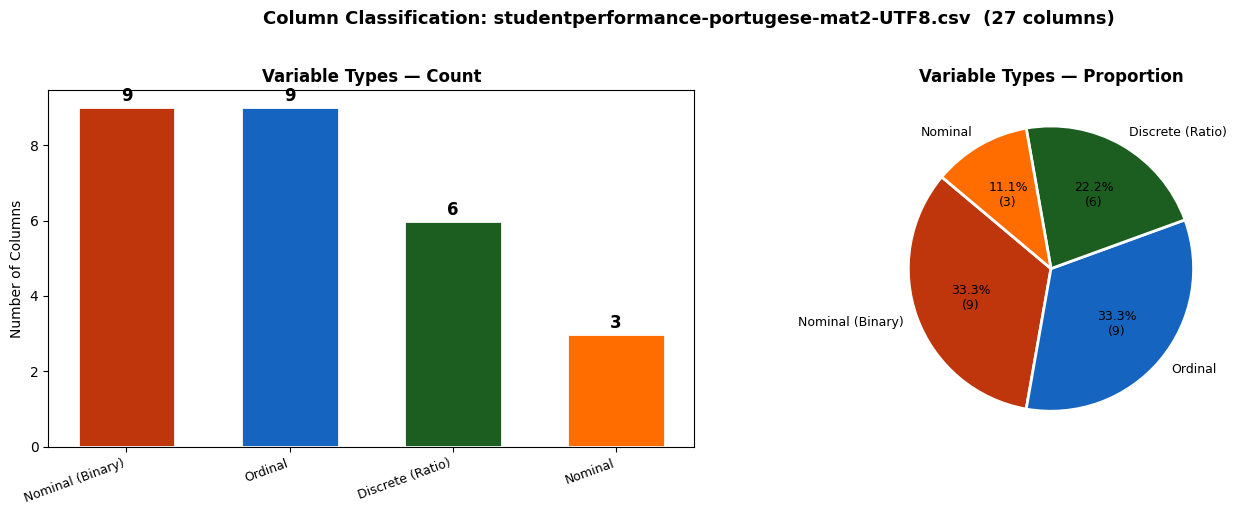

In [112]:
if df is None:
    print("⚠️  No data loaded.")
else:
    type_counts = classification_df['Scale Type'].value_counts()

    print(f"Final Classification Summary — '{CSV_FILE}'")
    print(f"{'Scale Type':<32} {'Count':>5}  Columns")
    print("─" * 85)
    for st, cnt in type_counts.items():
        cols = classification_df.loc[classification_df['Scale Type']==st, 'Column Label'].tolist()
        print(f"  {st:<30} {cnt:>4}   {', '.join(cols)}")
    print("─" * 85)
    print(f"  {'TOTAL':<30} {type_counts.sum():>4}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    bc = [SCALE_COLORS.get(t,('#888','#eee'))[0] for t in type_counts.index]
    bars = axes[0].bar(range(len(type_counts)), type_counts.values,
                       color=bc, edgecolor='white', linewidth=2, width=0.6)
    axes[0].set_xticks(range(len(type_counts)))
    axes[0].set_xticklabels(type_counts.index, rotation=20, ha='right', fontsize=9)
    axes[0].set_title('Variable Types — Count', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Number of Columns')
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x()+bar.get_width()/2., h+0.05,
                     str(int(h)), ha='center', va='bottom', fontweight='bold', fontsize=12)

    axes[1].pie(type_counts.values, labels=type_counts.index,
                autopct=lambda p: f'{p:.1f}%\n({int(round(p*type_counts.sum()/100))})',
                colors=bc, startangle=140,
                wedgeprops={'edgecolor':'white','linewidth':2},
                textprops={'fontsize':9})
    axes[1].set_title('Variable Types — Proportion', fontsize=12, fontweight='bold')

    plt.suptitle(f'Column Classification: {CSV_FILE}  ({len(classification_df)} columns)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### Q1(b): Distribution across Schools and Gender

🏫 School:
  GP: 349 (88.4%)
  MS: 46 (11.6%)

👥 Gender:
  Female: 208 (52.7%)
  Male: 187 (47.3%)


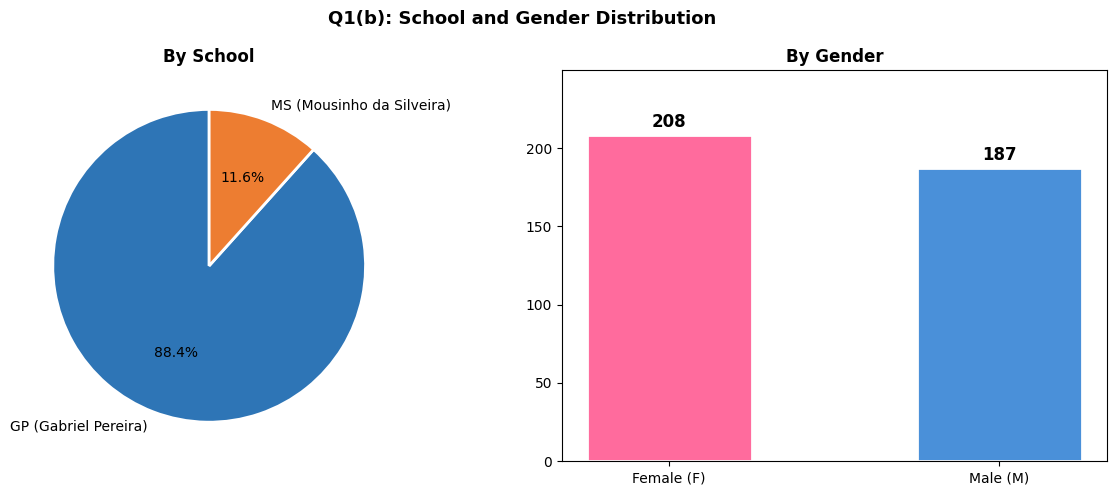

In [ ]:
if df is None:
    print("⚠️  No data loaded.")
else:
    school_counts = df['school'].value_counts()
    school_pct    = df['school'].value_counts(normalize=True) * 100
    sex_counts    = df['sex'].value_counts()
    sex_pct       = df['sex'].value_counts(normalize=True) * 100

    print("🏫 School:");
    [print(f"  {s}: {school_counts[s]} ({school_pct[s]:.1f}%)") for s in school_counts.index]
    print("\n👥 Gender:");
    gmap = {'F':'Female','M':'Male'}
    [print(f"  {gmap.get(g,g)}: {sex_counts[g]} ({sex_pct[g]:.1f}%)") for g in sex_counts.index]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].pie(school_counts.values,
                labels=['GP (Gabriel Pereira)','MS (Mousinho da Silveira)'],
                autopct='%1.1f%%', colors=['#2E75B6','#ED7D31'],
                startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
    axes[0].set_title('By School', fontsize=12, fontweight='bold')
    bars = axes[1].bar(['Female (F)','Male (M)'], sex_counts.values,
                       color=['#FF6B9D','#4A90D9'], edgecolor='white', linewidth=2, width=0.5)
    axes[1].set_title('By Gender', fontsize=12, fontweight='bold')
    axes[1].set_ylim(0, max(sex_counts.values)*1.2)
    for bar, val in zip(bars, sex_counts.values):
        axes[1].text(bar.get_x()+bar.get_width()/2., bar.get_height()+3,
                     str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
    plt.suptitle('Q1(b): School and Gender Distribution', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

### Q1(c): Age Distribution

count    395.00
mean      16.70
std        1.28
min       15.00
25%       16.00
50%       17.00
75%       18.00
max       22.00
Name: age, dtype: float64

  Age 15:  82 (20.8%) ██████████
  Age 16: 104 (26.3%) █████████████
  Age 17:  98 (24.8%) ████████████
  Age 18:  82 (20.8%) ██████████
  Age 19:  24 (6.1%) ███
  Age 20:   3 (0.8%) 
  Age 21:   1 (0.3%) 
  Age 22:   1 (0.3%) 


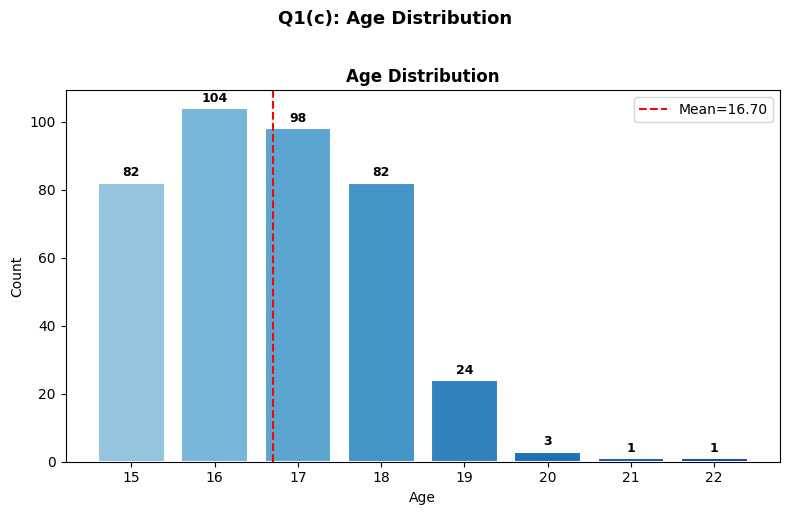

In [164]:
if df is None:
    print("⚠️  No data loaded.")
else:
    age_counts = df['age'].value_counts().sort_index()
    print(df['age'].describe().round(2))
    print()
    for age, count in age_counts.items():
        pct = count / df['age'].notna().sum() * 100
        print(f"  Age {int(age):2d}: {count:3d} ({pct:.1f}%) {'█'*int(pct/2)}")

    fig, ax = plt.subplots(figsize=(8, 5))
    ages = age_counts.index.astype(int)
    cg = plt.cm.Blues(np.linspace(0.4, 0.9, len(ages)))
    bars = ax.bar(ages, age_counts.values, color=cg, edgecolor='white', linewidth=1.5)
    ax.axvline(df['age'].mean(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Mean={df["age"].mean():.2f}')
    ax.set_title('Age Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Age'); ax.set_ylabel('Count')
    ax.set_xticks(ages); ax.legend()
    for bar, val in zip(bars, age_counts.values):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+1,
                     str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.suptitle('Q1(c): Age Distribution', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()

### Q1(d): Urban vs Rural

In [133]:
if df is None:
    print("⚠️  No data loaded.")
elif 'address' in df.columns:
    ac = df['address'].value_counts()
    ap = df['address'].value_counts(normalize=True)*100
    lm = {'U':'Urban','R':'Rural'}
    [print(f"  {lm.get(a,a)}: {ac[a]} ({ap[a]:.1f}%)") for a in ac.index]
else:
    print("⚠️  'address' column not found in this CSV.")
    print("   Reference (original UCI dataset): Urban ≈ 77.3%  |  Rural ≈ 22.7%")

  urban: 198 (50.1%)
  rural: 197 (49.9%)


### Q1(e): Higher Education Aspiration

  Wants higher edu: 375 (94.9%)
  Does NOT want: 20 (5.1%)


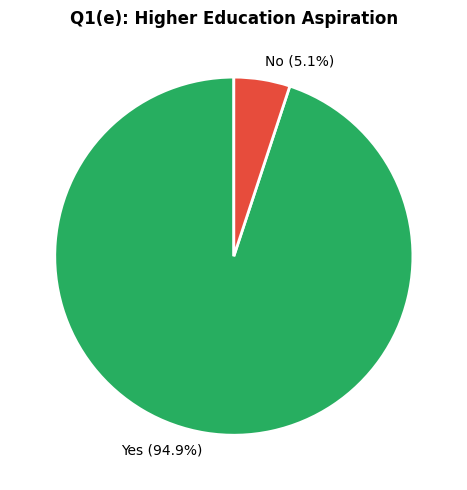

In [135]:
if df is None:
    print("⚠️  No data loaded.")
else:
    hc = df['higher'].value_counts()
    hp = df['higher'].value_counts(normalize=True)*100
    for h in hc.index:
        print(f"  {'Wants higher edu' if h=='yes' else 'Does NOT want'}: {hc[h]} ({hp[h]:.1f}%)")

    fig, ax = plt.subplots(figsize=(6,5))
    ax.pie(hc.values,
           labels=[f"Yes ({hp['yes']:.1f}%)", f"No ({hp['no']:.1f}%)"],
           colors=['#27AE60','#E74C3C'], startangle=90,
           wedgeprops={'edgecolor':'white','linewidth':2})
    ax.set_title('Q1(e): Higher Education Aspiration', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 🧹 Part 2: Data Quality & Cleaning

### Q2(a): Missing Values

In [157]:
print('Total missing Values are:', df.isnull().sum().sum())


Total missing Values are: 42


In [156]:
print(df.isnull().sum())


Sno            0
school         0
sex            0
age            0
Medu           0
Fedu           0
Mjob           0
Fjob           0
reason         0
traveltime     8
studytime     10
failures       0
schoolsup      0
famsup         0
paid           0
activities     0
higher         0
internet       0
famrel         0
freetime       0
goout          0
health         0
absences       0
G1             7
G2             8
G3             9
address        0
dtype: int64


### Q2(b): Invalid Age Values

In [150]:
if df is None:
    print("⚠️  No data loaded.")
else:
    invalid_age = df[(df['age']<15)|(df['age']>22)]
    print(f"  age < 15 : {len(df[df['age']<15])}")
    print(f"  age > 22 : {len(df[df['age']>22])}")
    print(f"  Total invalid: {len(invalid_age)}")
    print("  ✅ PASS" if len(invalid_age)==0 else f"  ❌ FAIL — {len(invalid_age)} records")

  age < 15 : 0
  age > 22 : 0
  Total invalid: 0
  ✅ PASS


### Q2(c): Duplicate Records

In [151]:
if df is None:
    print("⚠️  No data loaded.")
else:
    dup = df.duplicated().sum()
    print(f"Duplicate rows: {dup}")
    print("✅ PASS — all records unique" if dup==0 else f"⚠️  {dup} duplicates found")

Duplicate rows: 0
✅ PASS — all records unique


### Q2(d): Grade Validity (G1, G2, G3)

Column      Min    Max   Out-of-Range   Status
──────────────────────────────────────────────────
  G1          3     19              0  ✅ VALID
  G2          0     19              0  ✅ VALID
  G3          0     20              0  ✅ VALID

           G1      G2      G3
count  388.00  387.00  386.00
mean    10.92   10.75   10.40
std      3.33    3.78    4.58
min      3.00    0.00    0.00
25%      8.00    9.00    8.00
50%     11.00   11.00   11.00
75%     13.00   13.00   14.00
max     19.00   19.00   20.00


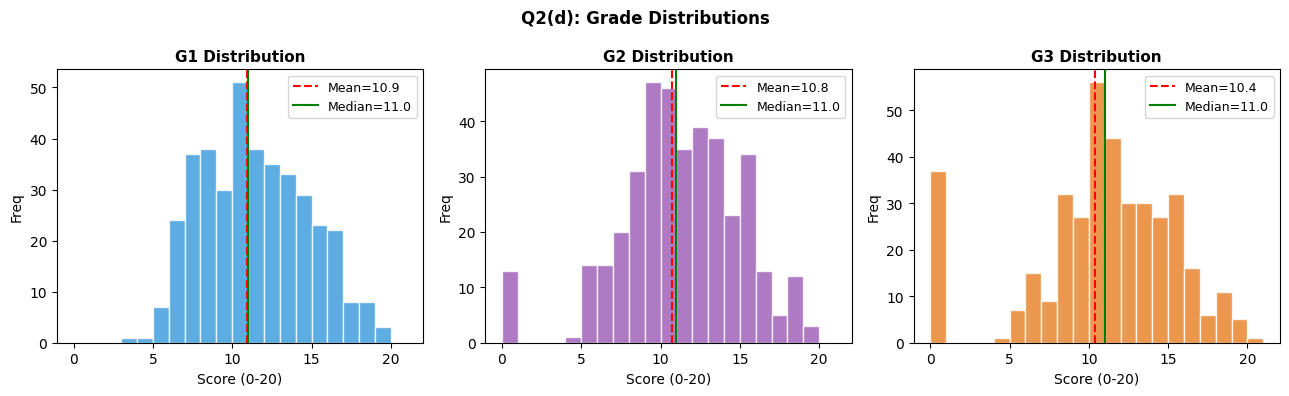

In [152]:
if df is None:
    print("⚠️  No data loaded.")
else:
    print(f"{'Column':<8} {'Min':>6} {'Max':>6} {'Out-of-Range':>14} {'Status':>8}")
    print("─"*50)
    for col in ['G1','G2','G3']:
        mn,mx = df[col].min(), df[col].max()
        bad = df[(df[col]<0)|(df[col]>20)]
        print(f"  {col:<6} {mn:>6.0f} {mx:>6.0f} {len(bad):>14}  {'✅ VALID' if len(bad)==0 else '❌ INVALID'}")
    print()
    print(df[['G1','G2','G3']].describe().round(2))

    fig, axes = plt.subplots(1,3,figsize=(13,4))
    for i,(col,color) in enumerate(zip(['G1','G2','G3'],['#3498DB','#9B59B6','#E67E22'])):
        data = df[col].dropna()
        axes[i].hist(data, bins=range(0,22), color=color, alpha=0.8, edgecolor='white')
        axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean={data.mean():.1f}')
        axes[i].axvline(data.median(), color='green', linestyle='-', linewidth=1.5, label=f'Median={data.median():.1f}')
        axes[i].set_title(f'{col} Distribution', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Score (0-20)'); axes[i].set_ylabel('Freq'); axes[i].legend(fontsize=9)
    plt.suptitle('Q2(d): Grade Distributions', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

### Q2(e): Completeness Percentage

Completeness = [(Total − Missing) / Total] × 100
  Total cells    : 395 × 27 = 10,665
  Missing cells  : 42
  Present cells  : 10,623
  Completeness   : 99.61%
  ✅ EXCELLENT


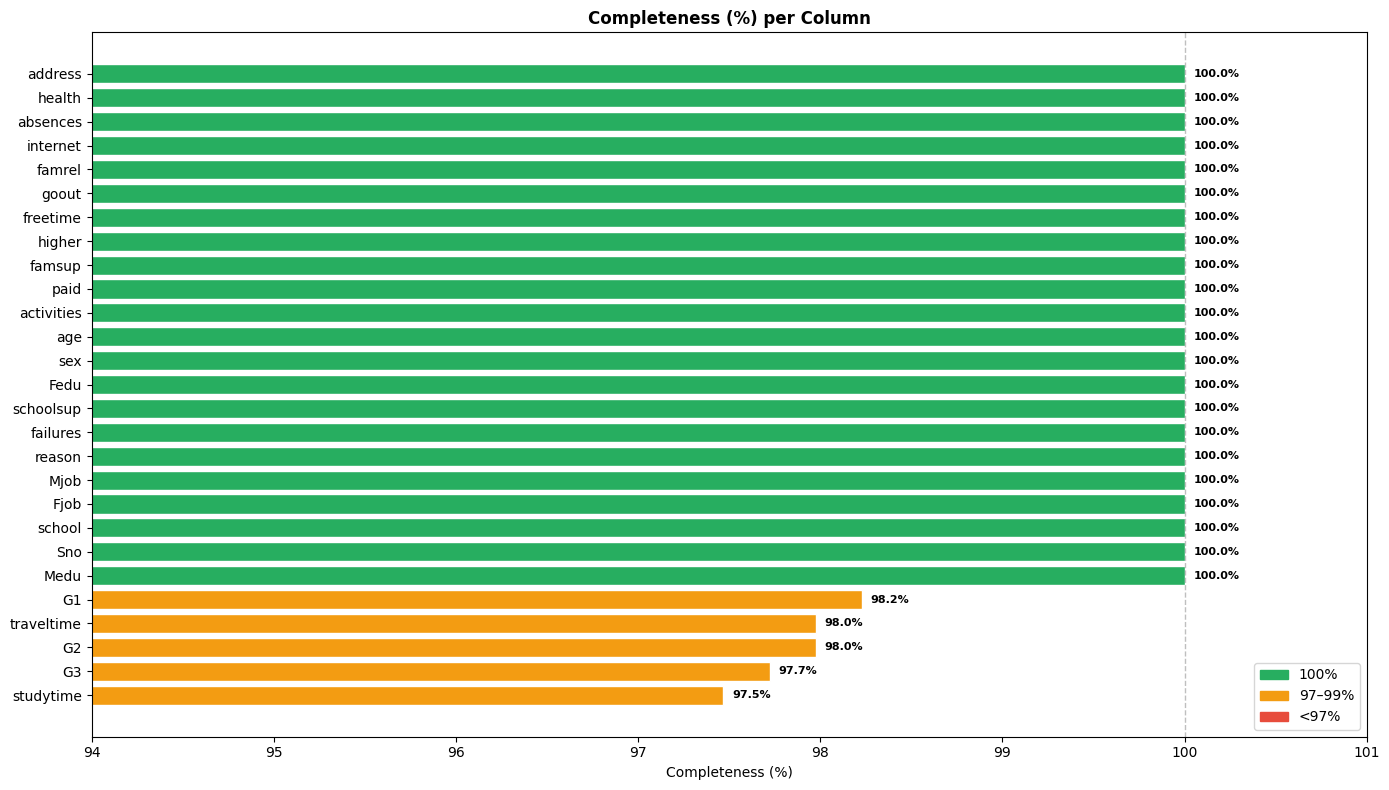

In [165]:
if df is None:
    print("⚠️  No data loaded.")
else:
    total_cells   = df.shape[0]*df.shape[1]
    missing_cells = df.isnull().sum().sum()
    present_cells = total_cells - missing_cells
    completeness  = present_cells/total_cells*100

    print("Completeness = [(Total − Missing) / Total] × 100")
    print("="*50)
    print(f"  Total cells    : {df.shape[0]} × {df.shape[1]} = {total_cells:,}")
    print(f"  Missing cells  : {missing_cells}")
    print(f"  Present cells  : {present_cells:,}")
    print(f"  Completeness   : {completeness:.2f}%")
    print("="*50)
    print(f"  {'✅ EXCELLENT' if completeness>=95 else ('⚠️ ACCEPTABLE' if completeness>=85 else '❌ POOR')}")

    cc = (df.notna().sum()/len(df)*100).sort_values()
    fig, ax = plt.subplots(figsize=(14,8))
    clrs2 = ['#27AE60' if v==100 else '#F39C12' if v>=97 else '#E74C3C' for v in cc.values]
    ax.barh(cc.index, cc.values, color=clrs2, edgecolor='white')
    ax.axvline(100, color='grey', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlim(94,101)
    ax.set_title('Completeness (%) per Column', fontsize=12, fontweight='bold')
    ax.set_xlabel('Completeness (%)')
    for bar, val in zip(ax.patches, cc.values):
        ax.text(val+0.05, bar.get_y()+bar.get_height()/2.,
                f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')
    ax.legend(handles=[
        mpatches.Patch(color='#27AE60',label='100%'),
        mpatches.Patch(color='#F39C12',label='97–99%'),
        mpatches.Patch(color='#E74C3C',label='<97%')
    ], loc='lower right')
    plt.tight_layout(); plt.show()

---
## 📋 Final Summary

In [166]:
if df is None:
    print("⚠️  No data loaded.")
else:
    print("="*62)
    print("         LAB 1 SUMMARY — CASE STUDY 1")
    print("="*62)
    print(f"  File          : {CSV_FILE}")
    print(f"  Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print()
    print("  VARIABLE CLASSIFICATION:")
    for st, cnt in classification_df['Scale Type'].value_counts().items():
        print(f"    {st:<32}: {cnt} column(s)")
    print()
    print("  DATA QUALITY:")
    print(f"    Missing values  : {df.isnull().sum().sum()} cells across {(df.isnull().sum()>0).sum()} col(s)")
    print(f"    Duplicate rows  : {df.duplicated().sum()}")
    print(f"    Completeness    : {(df.notna().sum().sum()/(df.shape[0]*df.shape[1])*100):.2f}%")
    print("="*62)

         LAB 1 SUMMARY — CASE STUDY 1
  File          : studentperformance-portugese-mat2-UTF8.csv
  Shape         : 395 rows × 27 columns

  VARIABLE CLASSIFICATION:
    Nominal (Binary)                : 9 column(s)
    Ordinal                         : 9 column(s)
    Discrete (Ratio)                : 6 column(s)
    Nominal                         : 3 column(s)

  DATA QUALITY:
    Missing values  : 42 cells across 5 col(s)
    Duplicate rows  : 0
    Completeness    : 99.61%


---
**End of Lab 1 | 25MT1306E — MDSA**

> 💡 **To analyse a different dataset:** Go back to **Step 1** — click *Upload CSV* — then **Run All Cells** (`Kernel → Restart & Run All`).